# 🛒 Walmart Store Sales Forecasting

## 🎯 商业背景 (Business Context)
> 你是 Walmart 的 Senior Data Analyst。公司有 **45 家门店**，
> 管理层需要你预测各门店的**周销售额 (Weekly Sales)**，以优化库存与促销排期。

## 📦 数据集 (单一 CSV，不需要 JOIN!)
| 字段 | 含义 | 类型 |
| :--- | :--- | :--- |
| `Store` | 门店编号 (1-45) | **分类特征** → 可做 Per-Store 时序特征 |
| `Date` | 日期 (周级别) | **时间索引** |
| `Weekly_Sales` | 周销售额 💰 | **预测目标** (Target) |
| `Holiday_Flag` | 是否假日周 (0/1) | **已标记好** ✅ |
| `Temperature` | 当周平均温度 (°F) | 外部特征 |
| `Fuel_Price` | 油价 | 外部特征 (宏观经济) |
| `CPI` | 消费者价格指数 | 外部特征 (通胀) |
| `Unemployment` | 失业率 | 外部特征 (经济) |

## 🆚 对比上一个项目 (Superstore → Walmart)
| 维度 | Superstore (已完成) | **Walmart (本次)** |
| :--- | :--- | :--- |
| 表数量 | 1 张 | **1 张** (无需 JOIN!) |
| 品类维度 | 有但没用 | **45 家门店** → Per-Store 特征 |
| 外部特征 | 无 | **温度 + 油价 + CPI + 失业率** |
| 时间粒度 | 日 (Daily) | **周 (Weekly)** → 波动更小 |
| Holiday | 无 | **已标记** (Holiday_Flag) |

## 🛣️ 路线图 (Roadmap)
1. **🧹 Data Prep**: 加载 → 时间解析 → 检查缺失值
2. **📊 EDA**: 门店对比 → 时间趋势 → 假日效应 → 外部特征相关性
3. **🔧 Feature Eng**: 日期特征 + **Per-Store Lag/Diff/Rolling** + 外部特征处理
4. **🔮 Modeling**: XGBoost + Early Stopping + Feature Importance 检查
5. **📉 Evaluation**: 分层评估 + 按门店 MAE + 残差分析
6. **💡 Insights**: 哪些门店好预测？假日/油价对销量影响多大？

---

## ⛽️ 函数加油站 (Function Cheat Sheet)

| 函数 | 作用 (大白话) | 常用参数 | SQL 类比 |
| :--- | :--- | :--- | :--- |
| `pd.to_datetime()` | 字符串 → 时间 | `format='%d-%m-%Y'` | `CAST(col AS DATE)` |
| `df.groupby('Store').shift(n)` | 按门店取滞后值 | `shift(4)` = 4 周前 | `LAG(col,n) OVER(PARTITION BY store)` |
| `df.groupby('Store').rolling(n)` | 按门店滑动均值 | `.mean()` | `AVG() OVER(PARTITION BY store ROWS n)` |
| `df.groupby('Store').diff(n)` | 按门店做差分 | `diff(4)` = 跟4周前比 | `col - LAG(col,n) OVER(PARTITION BY store)` |

> **⚠️ 关键区别**: 这次所有 Lag/Diff/Rolling 必须 `groupby('Store')` 再算！
> 不能跨门店取滞后值（1号店的上周值 ≠ 2号店的上周值）

## 1. 数据导入 (Data Loading)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 5)
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', lambda x: '%.2f' % x)

# 加载数据 (只有一张表！)
df = pd.read_csv('data/walmart/Walmart_Sales.csv')

print(f'Shape: {df.shape}')
print(f'Stores: {df["Store"].nunique()}')
print(f'Date range: {df["Date"].min()} ~ {df["Date"].max()}')
df.head()

Shape: (6435, 8)
Stores: 45
Date range: 01-04-2011 ~ 31-12-2010


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.57,211.10,8.11
1,1,12-02-2010,1641957.44,1,38.51,2.55,211.24,8.11
2,1,19-02-2010,1611968.17,0,39.93,2.51,211.29,8.11
3,1,26-02-2010,1409727.59,0,46.63,2.56,211.32,8.11
4,1,05-03-2010,1554806.68,0,46.50,2.62,211.35,8.11


---

## 2. 数据准备 (Data Preparation)
> **任务**:
> 1. 将 `Date` 转为 datetime 类型 (注意格式: `DD-MM-YYYY`)
> 2. 按日期排序 (时序数据必须有序！)
> 3. 检查缺失值和异常值
> 4. 快速可视化：选 2-3 家门店画时间序列

**🤔 思考**:
- 日期格式是 `DD-MM-YYYY` 还是 `MM-DD-YYYY`？
- 有没有缺失的周？
- 45 家门店的销量级别差距大吗？

In [2]:
df.columns = df.columns.str.lower()
df['date'] = pd.to_datetime(df['date'],format='%d-%m-%Y')


In [3]:
df['date'].dt.day_name().value_counts()
# 应该会看到全是 'Friday'


date
Friday    6435
Name: count, dtype: int64

In [4]:
START_DATE = df['date'].min()
END_DATE = df['date'].max()

full_range = pd.date_range(start=START_DATE,end=END_DATE,freq='W-FRI') 
df = pd.merge(pd.DataFrame({'date':full_range}),df,how='left',on='date')

df.isnull().sum()
df = df.sort_values(by=['store', 'date'], ascending=True)

In [5]:
df.head()
# df.tail()


,date,store,weekly_sales,holiday_flag,temperature,fuel_price,cpi,unemployment
0,2010-02-05,1,1643690.90,0,42.31,2.57,211.10,8.11
45,2010-02-12,1,1641957.44,1,38.51,2.55,211.24,8.11
90,2010-02-19,1,1611968.17,0,39.93,2.51,211.29,8.11
135,2010-02-26,1,1409727.59,0,46.63,2.56,211.32,8.11
180,2010-03-05,1,1554806.68,0,46.50,2.62,211.35,8.11


---

## 3. 探索性数据分析 (EDA)
> **任务**:
> 1. 各门店平均周销量对比 (bar chart)
> 2. 时间维度：总销量趋势 + 年/月周期性
> 3. Holiday 效应：假日周 vs 非假日周 销量差异
> 4. 外部特征相关性：Temperature / Fuel_Price / CPI / Unemployment 与 Sales 的关系

**🤔 思考**:
- 温度和销量是正相关还是负相关？（提示：想想空调/暖气季）
- CPI (通胀) 上升，销量是涨还是跌？

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          6435 non-null   datetime64[ns]
 1   store         6435 non-null   int64         
 2   weekly_sales  6435 non-null   float64       
 3   holiday_flag  6435 non-null   int64         
 4   temperature   6435 non-null   float64       
 5   fuel_price    6435 non-null   float64       
 6   cpi           6435 non-null   float64       
 7   unemployment  6435 non-null   float64       
dtypes: datetime64[ns](1), float64(5), int64(2)
memory usage: 452.5 KB


<Axes: xlabel='date', ylabel='weekly_sales'>

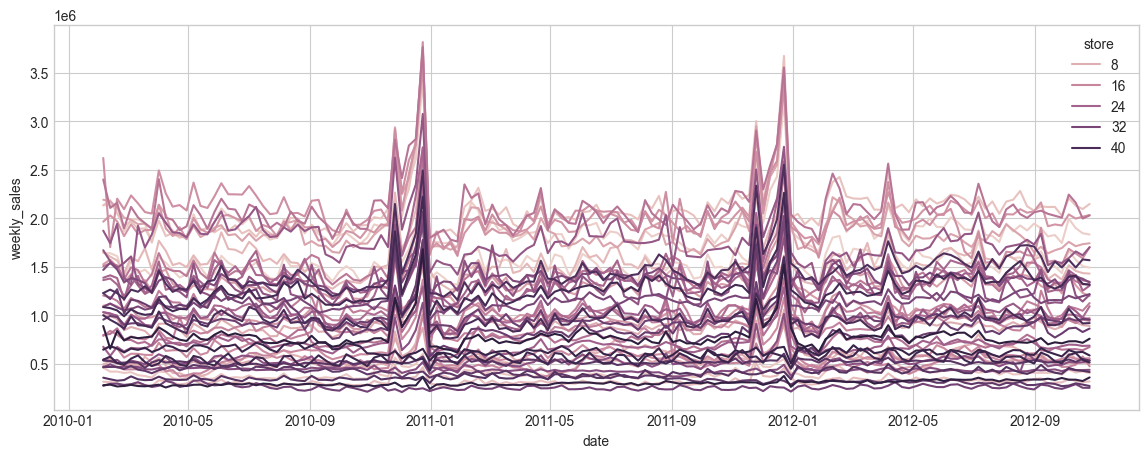

In [7]:
sns.lineplot(df,x='date',y='weekly_sales',hue='store')

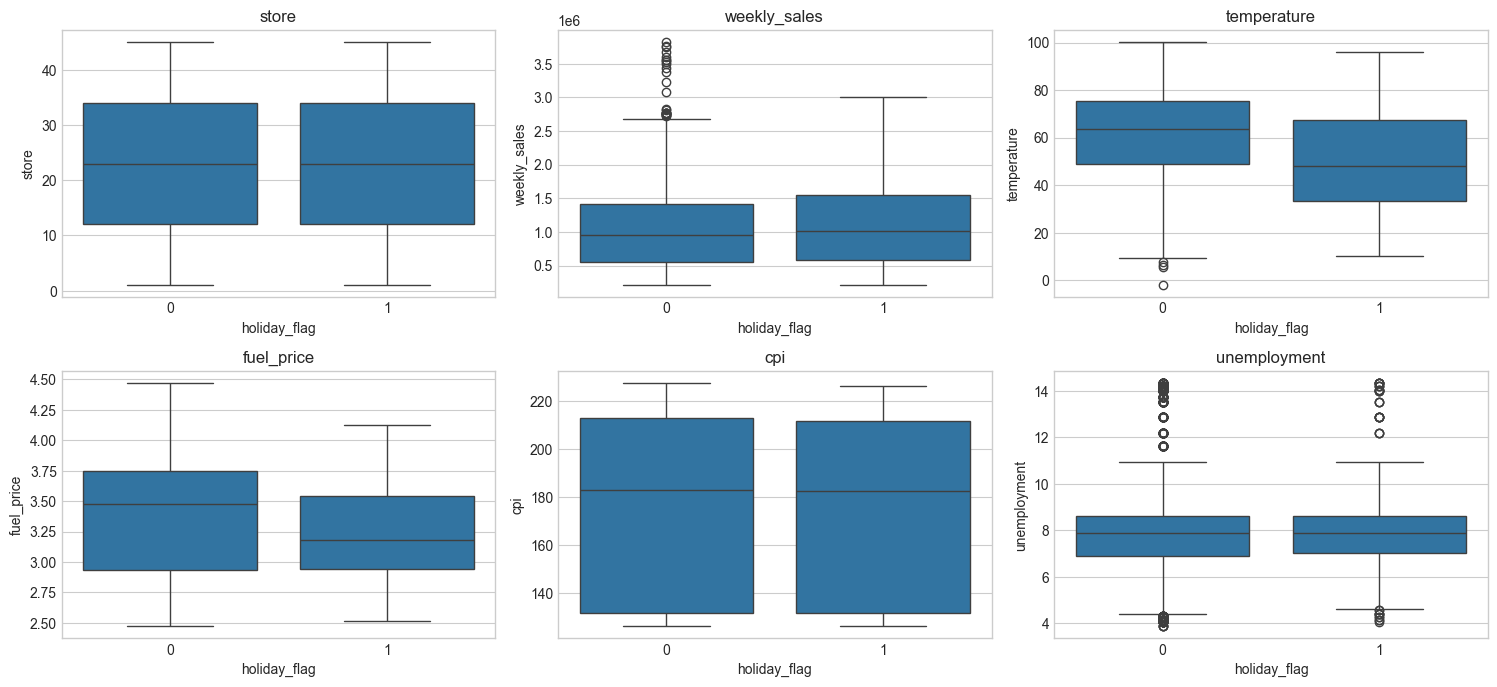

In [8]:
# 1. 自动筛选所有数值列 (排除掉 label)
num_cols = df.select_dtypes(include=['number']).columns.tolist()
if 'holiday_flag' in num_cols: num_cols.remove('holiday_flag')

# 2. 循环画图 (subplot)
plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols):
    plt.subplot(3, 3, i+1) # 假设有9个变量，3x3排列
    sns.boxplot(data=df, x='holiday_flag', y=col) # 对比 label=0/1 的分布差异
    plt.title(col)
plt.tight_layout()

<Axes: >

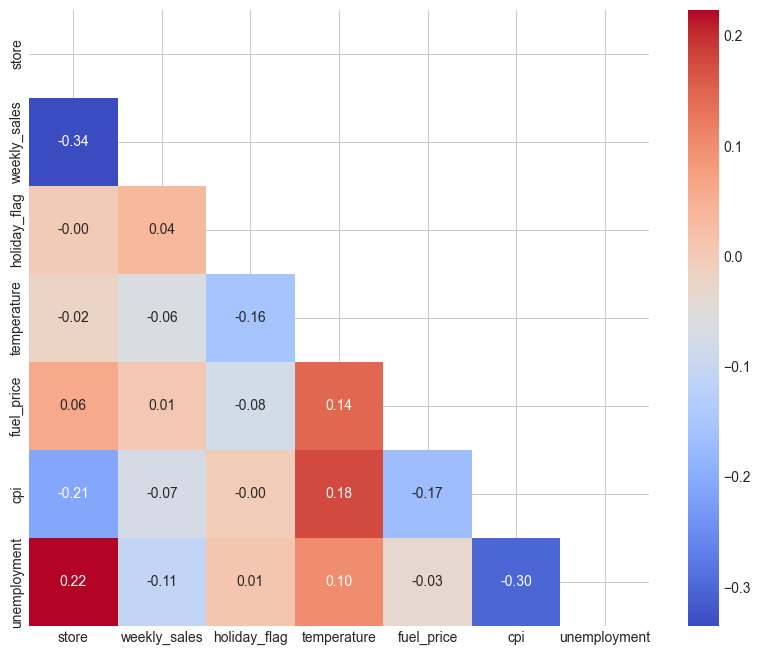

In [9]:
plt.figure(figsize=(10, 8))
corr = df.corr(numeric_only=True)
# mask=np.triu(...) 用于遮挡上半三角，看起来更 Senior
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', 
            mask=np.triu(np.ones_like(corr, dtype=bool)))

In [10]:
df.groupby('store')['weekly_sales'].mean().sort_values(ascending=False)

store
20   2107676.87
4    2094712.96
14   2020978.40
13   2003620.31
2    1925751.34
10   1899424.57
27   1775216.20
6    1564728.19
1    1555264.40
39   1450668.13
19   1444999.04
31   1395901.44
23   1389864.46
24   1356755.39
11   1356383.12
28   1323522.24
41   1268125.42
32   1166568.15
18   1084718.42
22   1028501.04
12   1009001.61
26   1002911.84
34    966781.56
40    964128.04
35    919724.98
8     908749.52
17    893581.39
45    785981.41
21    756069.08
25    706721.53
43    633324.72
15    623312.47
7     570617.31
42    556403.86
9     543980.55
29    539451.43
16    519247.73
37    518900.28
30    438579.62
3     402704.44
38    385731.65
36    373511.99
5     318011.81
44    302748.87
33    259861.69
Name: weekly_sales, dtype: float64

In [11]:
store_df = df[df['store']==20]
store_df

,date,store,weekly_sales,holiday_flag,temperature,fuel_price,cpi,unemployment
19,2010-02-05,20,2401395.47,0,25.92,2.78,204.25,8.19
64,2010-02-12,20,2109107.90,1,22.12,2.77,204.39,8.19
109,2010-02-19,20,2161549.76,0,25.43,2.75,204.43,8.19
154,2010-02-26,20,1898193.95,0,32.32,2.75,204.46,8.19
199,2010-03-05,20,2119213.72,0,31.75,2.78,204.49,8.19
...,...,...,...,...,...,...,...,...
6229,2012-09-28,20,2008350.58,0,58.65,4.00,215.74,7.28
6274,2012-10-05,20,2246411.89,0,60.77,3.98,215.93,7.29
6319,2012-10-12,20,2162951.36,0,47.20,4.00,216.12,7.29
6364,2012-10-19,20,1999363.49,0,56.26,3.97,216.15,7.29


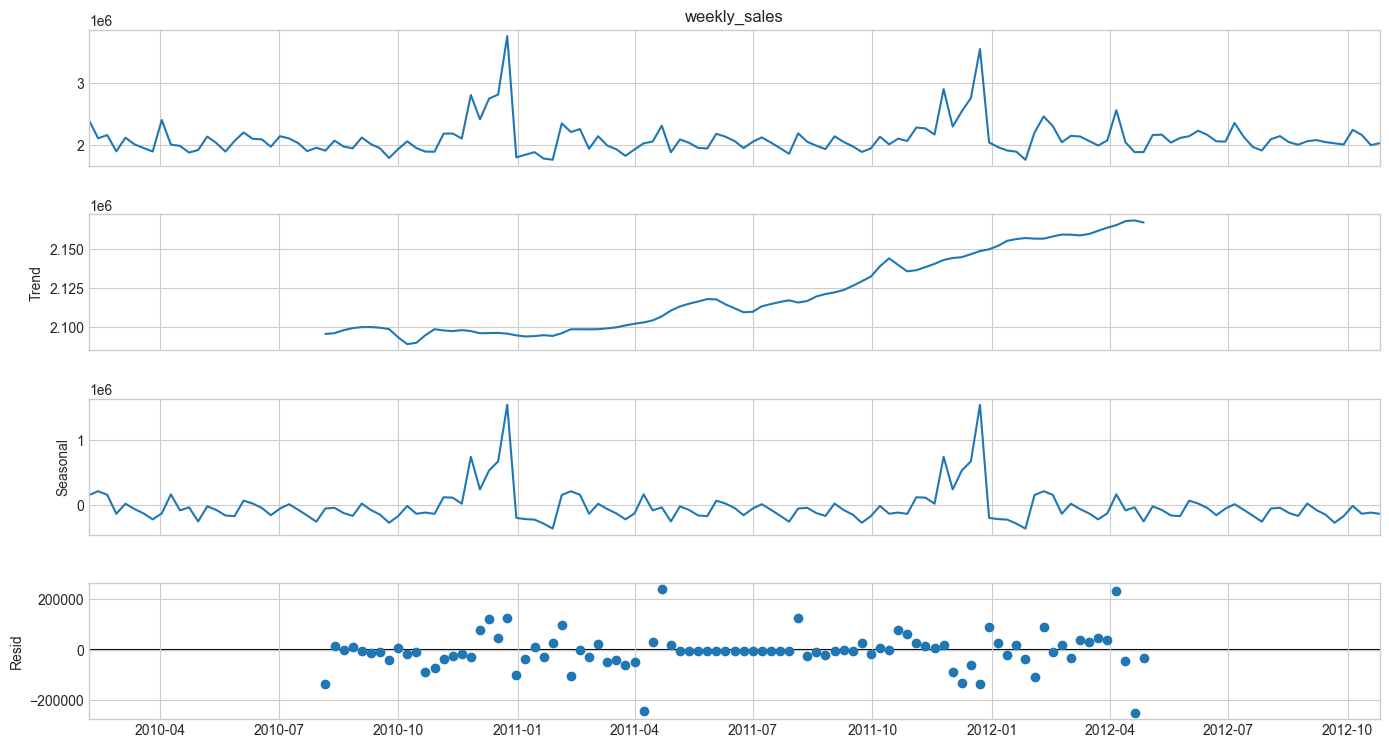

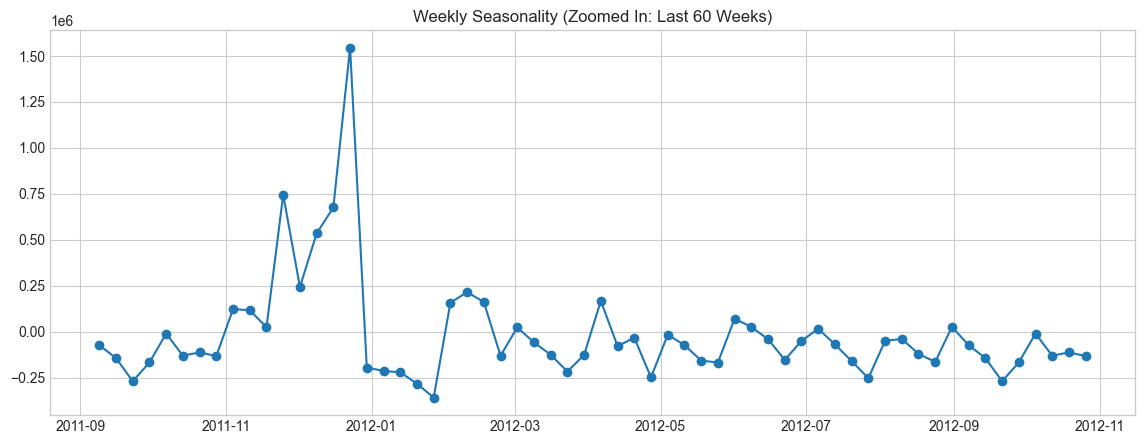

In [12]:
# ==========================================
# 📖 答疑: 季节性分解 (Seasonal Decompose)
# ==========================================
# 1. Additive (加法) vs Multiplicative (乘法)?
#    - Additive: y = Trend + Seasonality + Residual
#      (适用: 季节性波动幅度不随趋势变化，例如每年固定涨 1000 块)
#    - Multiplicative: y = Trend * Seasonality * Residual
#      (适用: 季节性波动幅度随趋势放大，例如每年固定涨 10%)
#    >>> Walmart 销量波动比较稳定，先用 'additive' (加法) 即可。
#
# 2. period 参数怎么填?
#    - 数据是周粒度 (Weekly)
#    - 我们想看'年'周期性 (Yearly Seasonality)
#    - 1 年 ≈ 52 周，所以 period=52
# ==========================================

from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

ts_data = store_df.set_index('date')['weekly_sales'].asfreq('W-FRI').fillna(0)

# 2. 执行分解
decomposition = seasonal_decompose(ts_data, model='additive', period=52)

# 3. 可视化
# 调整画布大小，让图表更清晰
fig = decomposition.plot()
fig.set_size_inches(14, 8)
plt.show()

# --- 进阶: Zoom In (放大看周度规律) ---
# 只看最后 60 天，验证周三/周四低谷，周五高峰
seasonal_weekly = decomposition.seasonal
subset = seasonal_weekly.iloc[-60:]

plt.figure(figsize=(14, 5))
plt.plot(subset.index, subset.values, marker='o') # 加点 marker 更清晰
plt.title('Weekly Seasonality (Zoomed In: Last 60 Weeks)')
plt.grid(True)
plt.show()

In [13]:
from statsmodels.tsa.stattools import adfuller

def adf_test(series, name=''):
    """ADF 平稳性检验 - 科学判断是否需要差分"""
    result = adfuller(series.dropna(), autolag='AIC')
    p_value = result[1]

    print(f'=== ADF 检验: {name} ===')
    print(f'  ADF Statistic : {result[0]:.4f}')
    print(f'  p-value       : {p_value:.4f}')
    print(f'  临界值 (5%)   : {result[4]["5%"]:.4f}')
    print(f'  结论: {"✅ 平稳" if p_value < 0.05 else "❌ 非平稳 (需差分)"}')
    return p_value

# 使用: 逐步检验，从原始序列开始
p0 = adf_test(df['weekly_sales'], '原始序列')
if p0 >= 0.05:
    p1 = adf_test(df['weekly_sales'].diff(1), 'diff(period=1)')

=== ADF 检验: 原始序列 ===
  ADF Statistic : -4.6241
  p-value       : 0.0001
  临界值 (5%)   : -2.8620
  结论: ✅ 平稳


---

## 4. 特征工程 (Feature Engineering) ⭐ 核心环节
> **任务**:
> 1. **日期特征**: year, month, weekofyear, is_month_start/end
> 2. **Per-Store 时序特征** (按 Store 分组):
>    - `sales_lag4`: 4 周前同店销量
>    - `sales_lag52`: 52 周前 (去年同期)
>    - `sales_rolling_mean_4`: 最近 4 周均值
>    - `sales_rolling_std_4`: 最近 4 周标准差
>    - `sales_diff4`: 跟 4 周前比的变化量
> 3. **外部特征处理**: 已经是数值型，直接可用 ✅

**💡 关键代码模式**:
```python
# 所有时序特征必须 groupby('Store') 再算！
df['sales_lag4'] = df.groupby('Store')['Weekly_Sales'].shift(4)
df['sales_rolling_mean_4'] = df.groupby('Store')['Weekly_Sales'].transform(
    lambda x: x.rolling(4).mean()
)
```

**⚠️ 注意**:
- 周级别数据：`shift(4)` = 4 周前 (不是 4 天前！)
- `shift(52)` = 去年同期 (52 周 ≈ 1 年)
- Lag/Rolling 产生的 NaN → 最后 `dropna()` 丢掉前面几周

In [14]:
df.columns

Index(['date', 'store', 'weekly_sales', 'holiday_flag', 'temperature',
       'fuel_price', 'cpi', 'unemployment'],
      dtype='object')

In [15]:
df_feature = df.copy()
cols_feature = ['weekly_sales', 'temperature','fuel_price', 'cpi', 'unemployment']

for cols in cols_feature:
       # lag features
       df_feature[f'{cols}_lag1week'] = df_feature.groupby('store')[cols].shift(1)
       df_feature[f'{cols}_lag4week'] = df_feature.groupby('store')[cols].shift(4)
       df_feature[f'{cols}_lag52week'] = df_feature.groupby('store')[cols].shift(52)
       # diff features 
       df_feature[f'{cols}_diff4week'] = df_feature.groupby('store')[cols].shift(1).diff(4)
       df_feature[f'{cols}_diff52week'] = df_feature.groupby('store')[cols].shift(1).diff(52)
       # rolling features
       df_feature[f'{cols}_rollingmean_4week'] = df_feature.groupby('store')[cols].transform(lambda x: x.shift(1).rolling(window=4).mean())
       df_feature[f'{cols}_rollingstd_4week'] = df_feature.groupby('store')[cols].transform(lambda x: x.shift(1).rolling(window=4).std())
       df_feature[f'{cols}_rollingmean_52week'] = df_feature.groupby('store')[cols].transform(lambda x: x.shift(1).rolling(window=52).mean())
       df_feature[f'{cols}_rollingstd_52week'] = df_feature.groupby('store')[cols].transform(lambda x: x.shift(1).rolling(window=52).std())

# 日期拆解 (date 都是周五)
df_feature['date'] = pd.to_datetime(df_feature['date'])
# df_feature['dayofweek'] → 删掉，全是周五=4，零方差
df_feature['month'] = df_feature['date'].dt.month
df_feature['year'] = df_feature['date'].dt.year
df_feature['dayofyear'] = df_feature['date'].dt.dayofyear
df_feature['weekofyear'] = df_feature['date'].dt.isocalendar().week.astype(int)  # 转 int 防类型问题
df_feature['quarter'] = df_feature['date'].dt.quarter

# 月初/月末周 (适用于周频数据)
df_feature['is_month_start_week'] = (df_feature['date'].dt.day <= 7).astype(int)
df_feature['is_month_end_week'] = (
    df_feature['date'].dt.month != (df_feature['date'] + pd.Timedelta(days=7)).dt.month
).astype(int)


In [16]:
df_feature.head()

,date,store,weekly_sales,holiday_flag,temperature,fuel_price,cpi,unemployment,weekly_sales_lag1week,weekly_sales_lag4week,...,unemployment_rollingstd_4week,unemployment_rollingmean_52week,unemployment_rollingstd_52week,month,year,dayofyear,weekofyear,quarter,is_month_start_week,is_month_end_week
0,2010-02-05,1,1643690.90,0,42.31,2.57,211.10,8.11,NaN,NaN,...,NaN,NaN,NaN,2,2010,36,5,1,1,0
45,2010-02-12,1,1641957.44,1,38.51,2.55,211.24,8.11,1643690.90,NaN,...,NaN,NaN,NaN,2,2010,43,6,1,0,0
90,2010-02-19,1,1611968.17,0,39.93,2.51,211.29,8.11,1641957.44,NaN,...,NaN,NaN,NaN,2,2010,50,7,1,0,0
135,2010-02-26,1,1409727.59,0,46.63,2.56,211.32,8.11,1611968.17,NaN,...,NaN,NaN,NaN,2,2010,57,8,1,0,1
180,2010-03-05,1,1554806.68,0,46.50,2.62,211.35,8.11,1409727.59,1643690.90,...,0.00,NaN,NaN,3,2010,64,9,1,1,0


In [17]:
df_feature.describe(include='all')

,date,store,weekly_sales,holiday_flag,temperature,fuel_price,cpi,unemployment,weekly_sales_lag1week,weekly_sales_lag4week,...,unemployment_rollingstd_4week,unemployment_rollingmean_52week,unemployment_rollingstd_52week,month,year,dayofyear,weekofyear,quarter,is_month_start_week,is_month_end_week
count,6435,6435.00,6435.00,6435.00,6435.00,6435.00,6435.00,6435.00,6390.00,6255.00,...,6255.00,4095.00,4095.00,6435.00,6435.00,6435.00,6435.00,6435.00,6435.00,6435.00
mean,2011-06-17 00:00:00,23.00,1046964.88,0.07,60.66,3.36,171.58,8.00,1047210.46,1047619.07,...,0.03,8.06,0.23,6.45,2010.97,180.76,25.82,2.48,0.23,0.23
min,2010-02-05 00:00:00,1.00,209986.25,0.00,-2.06,2.47,126.06,3.88,209986.25,209986.25,...,0.00,4.22,0.01,1.00,2010.00,6.00,1.00,1.00,0.00,0.00
25%,2010-10-08 00:00:00,12.00,553350.10,0.00,47.46,2.93,131.74,6.89,553834.78,553869.47,...,0.00,7.07,0.11,4.00,2010.00,97.00,14.00,2.00,0.00,0.00
50%,2011-06-17 00:00:00,23.00,960746.04,0.00,62.67,3.44,182.62,7.87,960971.98,960476.10,...,0.00,7.86,0.20,6.00,2011.00,181.00,26.00,2.00,0.00,0.00
75%,2012-02-24 00:00:00,34.00,1420158.66,0.00,74.94,3.73,212.74,8.62,1420935.02,1421209.38,...,0.00,8.59,0.33,9.00,2012.00,265.00,38.00,3.00,0.00,0.00
max,2012-10-26 00:00:00,45.00,3818686.45,1.00,100.14,4.47,227.23,14.31,3818686.45,3818686.45,...,0.42,14.16,0.79,12.00,2012.00,365.00,52.00,4.00,1.00,1.00
std,NaN,12.99,564366.62,0.26,18.44,0.46,39.36,1.88,564658.36,565436.19,...,0.06,1.86,0.15,3.24,0.80,99.05,14.13,1.07,0.42,0.42


---

## 5. 数据切分 (Train/Test Split)
> **任务**:
> 1. **按时间切分** (最后 N 周作为测试集)
> 2. 定义 `feature_cols` (去掉 Date, Weekly_Sales, Store)
> 3. 检查 Train/Test 的 y 分布

**🤔 思考**:
- Store 列是数字 (1-45)，但它是**分类特征**还是数值特征？
- 需不需要对 Store 做 One-Hot 编码？

In [18]:
# ✅ 动态计算切分点: 取后 20% 的时间跨度做测试集 (无魔法数字)
TEST_RATIO = 0.2
unique_dates = sorted(df_feature['date'].unique())
n_dates = len(unique_dates)
cutoff_idx = int(n_dates * (1 - TEST_RATIO))
cutoff_date = unique_dates[cutoff_idx]

# 按日期切分 (所有 Store 统一切)
train_mask = df_feature['date'] <= cutoff_date
test_mask  = df_feature['date'] > cutoff_date

X = df_feature.select_dtypes(include='number').drop(columns=['weekly_sales'])
y = df_feature['weekly_sales']

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]

print(f"切分点: {cutoff_date.date()}")
print(f"训练集: {train_mask.sum()} 行 | 测试集: {test_mask.sum()} 行")

切分点: 2012-04-13
训练集: 5175 行 | 测试集: 1260 行


最近的数据权重 (Date: 2012-04-13): 1.0000
最旧的数据权重 (Date: 2010-02-05): 0.4502


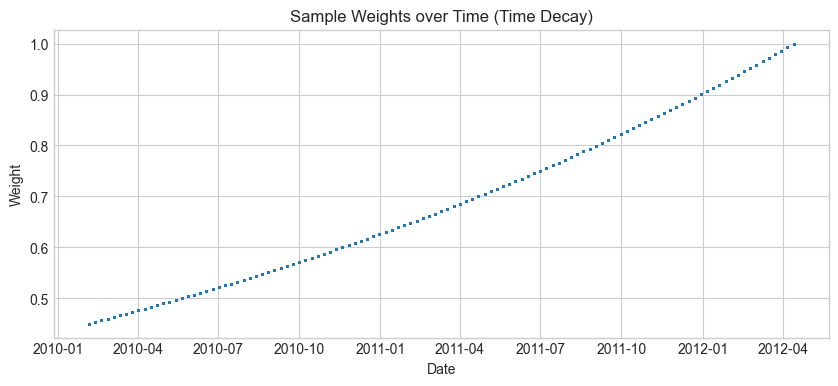

In [42]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 拿到训练集的日期 (注意: X_train 里没有日期列，要回 df_feature 拿)
train_dates = df_feature.loc[train_mask, 'date']
max_date = train_dates.max()

# 2. 计算"距离今天多久" (天数差)
# 也就是: 2012-04-13 是 0 天, 2010-02-05 是 800 天
days_diff = (max_date - train_dates).dt.days

# 3. 计算衰减权重
# decay_rate 越大，旧数据衰减越快 (0.001 是一个温和的参数)
DECAY_RATE = 0.001
SAMPLE_WEIGHTS = np.exp(-DECAY_RATE * days_diff)

# 4. (可选) 看一眼权重分布
print(f"最近的数据权重 (Date: {max_date.date()}): {SAMPLE_WEIGHTS.max():.4f}")
print(f"最旧的数据权重 (Date: {train_dates.min().date()}): {SAMPLE_WEIGHTS.min():.4f}")

plt.figure(figsize=(10, 4))
plt.scatter(train_dates, sample_weights, s=1)
plt.title("Sample Weights over Time (Time Decay)")
plt.xlabel("Date")
plt.ylabel("Weight")
plt.show()


---

## 6. 建模 (Modeling)
> **任务**:
> 1. XGBoost + Early Stopping
> 2. 训练后**立刻看 Feature Importance** → 检查 Data Leakage
> 3. 预测 & 计算 MAE

**🔧 参考参数**:
```python
xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    early_stopping_rounds=50,
    random_state=42,
    n_jobs=-1
)
```

In [21]:
# TODO: Feature Importance 可视化
# 提示:
# fi = pd.Series(model.feature_importances_, index=feature_cols)
# fi.sort_values().plot(kind='barh')
# ⚠️ 检查: 如果某个特征重要性 > 50%, 可能 Data Leakage!



In [45]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error,mean_absolute_percentage_error

xgb_model = XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    early_stopping_rounds=50,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train, y_train,
    sample_weight=SAMPLE_WEIGHTS,  # <--- 就是这里！
    eval_set=[(X_test, y_test)],   # 验证集
    verbose=10                     # 每10轮print一次
)

xgb_y_pred = xgb_model.predict(X_test)
mae = mean_absolute_error(y_test,xgb_y_pred)
mse = mean_squared_error(y_test,xgb_y_pred)
mape = mean_absolute_percentage_error(y_test, xgb_y_pred)

print(f'xgboost mae:{mae:.4f}')
print(f'xgboost mape{mape:.4f}')
print(f'xgboost mse:{mse:.4f}')



[0]	validation_0-rmse:507862.98839
[10]	validation_0-rmse:309317.93521
[20]	validation_0-rmse:189432.88446
[30]	validation_0-rmse:121462.92485
[40]	validation_0-rmse:83299.20447
[50]	validation_0-rmse:65621.52586
[60]	validation_0-rmse:58951.44908
[70]	validation_0-rmse:57519.70030
[80]	validation_0-rmse:57738.34917
[90]	validation_0-rmse:58135.44940
[100]	validation_0-rmse:58461.53309
[110]	validation_0-rmse:58542.34868
[119]	validation_0-rmse:58825.33046
xgboost mae:41872.5186
xgboost mape0.0468
xgboost mse:3308515943.0196


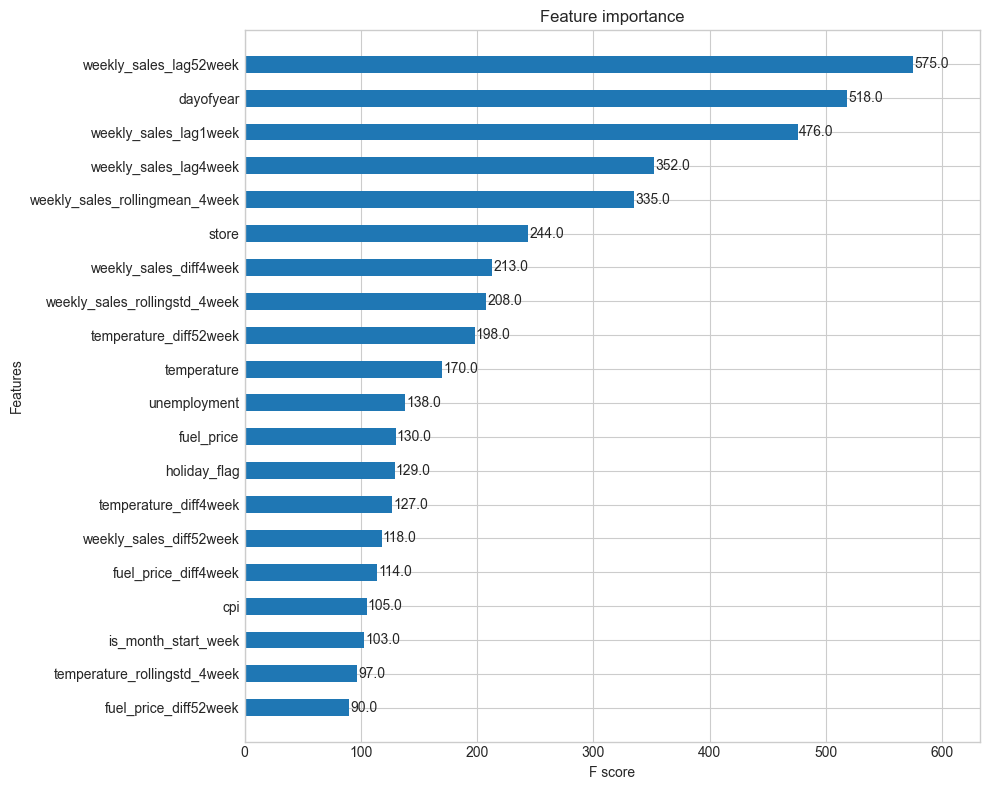

In [46]:
# 1. 画 Feature Importance (快速诊断)
import xgboost as xgb
fig, ax = plt.subplots(figsize=(10, 8))
xgb.plot_importance(xgb_model, ax=ax, height=0.5, max_num_features=20)
plt.tight_layout()
plt.show()

# # 2. 拿到数值排序 (高级用法)
# importances = xgb_model.feature_importances_
# feat_imp = pd.Series(importances, index=feature_cols).sort_values(ascending=False)
# print(feat_imp)

最难预测的 Top 5 门店:
 store
5    0.11
33   0.10
36   0.10
3    0.09
14   0.08
Name: mape, dtype: float64


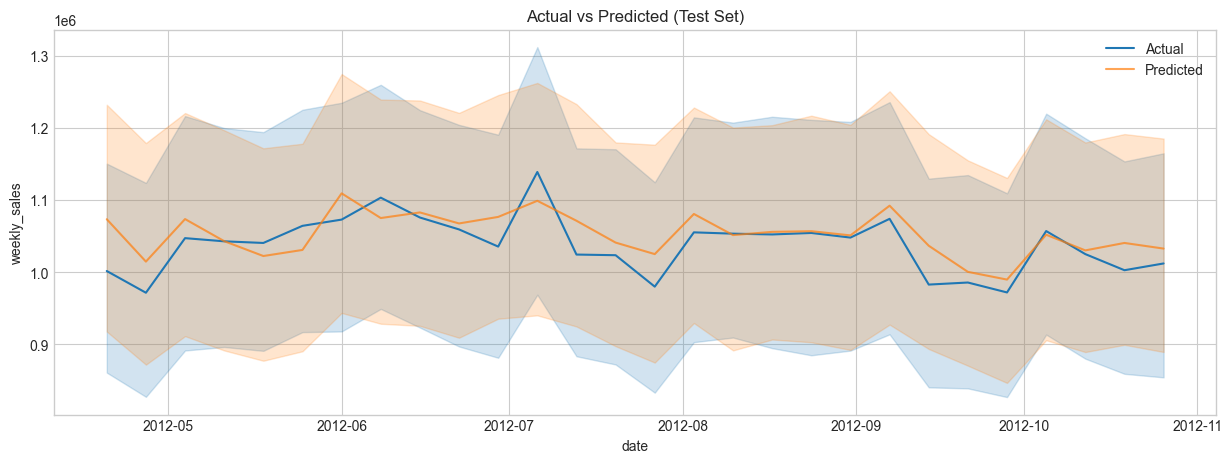

误差最大的 5 个样本:
            date  store  weekly_sales       pred     error  holiday_flag
5593 2012-06-22     14    1660228.88 1989283.75 329054.87             0
5728 2012-07-13     14    1544422.35 1848738.00 304315.65             0
5638 2012-06-29     14    1591835.02 1884451.75 292616.73             0
5194 2012-04-20     20    1884427.84 2159358.25 274930.41             0
5818 2012-07-27     14    1479514.66 1732100.62 252585.97             0


In [ ]:
# 1. 把预测结果拼回 Test Set

test_df = df_feature.loc[test_mask].copy()
test_df['pred'] = xgb_y_pred
test_df['error'] = abs(test_df['weekly_sales'] - test_df['pred'])
test_df['mape'] = test_df['error'] / test_df['weekly_sales']

# 2. 按 Store 排名：看看哪家店最难预测？
store_error = test_df.groupby('store')['mape'].mean().sort_values(ascending=False)
print("最难预测的 Top 5 门店:\n", store_error.head())

# 3. 按时间画图：看看是不是节假日预测得不好？
plt.figure(figsize=(15, 5))
sns.lineplot(data=test_df, x='date', y='weekly_sales', label='Actual')
sns.lineplot(data=test_df, x='date', y='pred', label='Predicted', alpha=0.7)
plt.title("Actual vs Predicted (Test Set)")
plt.show()

# 4. 把"坏 Case" 打印出来看看
bad_cases = test_df.nlargest(5, 'error')[['date', 'store', 'weekly_sales', 'pred', 'error', 'holiday_flag']]
print("误差最大的 5 个样本:\n", bad_cases)


In [49]:
# 1. 看看训练集的分数
train_pred = xgb_model.predict(X_train)
train_mape = mean_absolute_percentage_error(y_train, train_pred)

print(f"训练集 MAPE: {train_mape:.4f}")
print(f"测试集 MAPE: {mape:.4f}")  # 之前算的 0.0468


训练集 MAPE: 0.0511
测试集 MAPE: 0.0468


In [50]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor

# 1. 定义参数空间 (这是调参的"地图")
# 我们告诉计算机：在这个范围里帮我找最好的组合！
# 提示: 如果你不想让它跑太久，可以适当减少 n_estimators
param_dist = {
    'n_estimators': [100, 300, 500],
    'max_depth': [3, 5, 7, 9],              # 树越深越容易过拟合
    'learning_rate': [0.01, 0.05, 0.1, 0.2],# 学习率越低越稳，但需要更多树
    'subsample': [0.7, 0.8, 0.9],           # 每次只用一部分样本训练 (防过拟合)
    'colsample_bytree': [0.7, 0.8, 0.9]     # 每次只用一部分特征训练 (防过拟合)
}

# 2. 初始化 RandomizedSearchCV (性价比最高的方法)
random_search = RandomizedSearchCV(
    estimator=XGBRegressor(random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=10,          # ⚠️ 尝试 10 次 (你可以改成 20, 50...)
    scoring='neg_mean_absolute_percentage_error', # 目标：最小化 MAPE (注意是负数)
    cv=3,               # 3 折交叉验证
    verbose=1,
    n_jobs=-1,          # 使用所有 CPU 核心
    random_state=42
)

# 3. 开始搜索 (Sit back and relax ☕️)
print("🎲 Starting Randomized Search (10 iterations)... ")
random_search.fit(X_train, y_train)

# 4. 输出结果
print("\n🏆 Best Parameters Found:\n", random_search.best_params_)
print(f"🏆 Best CV Score (MAPE): {-random_search.best_score_:.4f}")

# 5. 用最好的参数重新预测 Test 集
best_model = random_search.best_estimator_
best_pred = best_model.predict(X_test)
best_mape = mean_absolute_percentage_error(y_test, best_pred)

print(f"\n🚀 Final Test MAPE (Tuned): {best_mape:.4f}")


🎲 Starting Randomized Search (10 iterations)... 
Fitting 3 folds for each of 10 candidates, totalling 30 fits

🏆 Best Parameters Found:
 {'subsample': 0.7, 'n_estimators': 500, 'max_depth': 5, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
🏆 Best CV Score (MAPE): 0.0868

🚀 Final Test MAPE (Tuned): 0.0411


最难预测的 Top 5 门店:
 store
14   0.09
7    0.06
3    0.06
38   0.06
16   0.06
Name: mape, dtype: float64


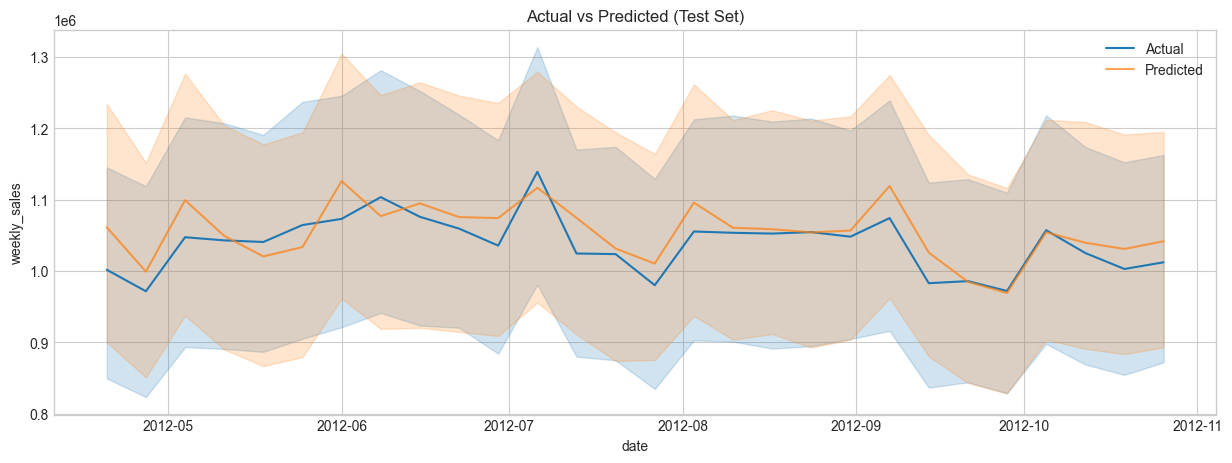

误差最大的 5 个样本:
            date  store  weekly_sales       pred     error  holiday_flag
5638 2012-06-29     14    1591835.02 1992166.38 400331.35             0
5593 2012-06-22     14    1660228.88 2040350.25 380121.37             0
5728 2012-07-13     14    1544422.35 1854090.00 309667.65             0
5194 2012-04-20     20    1884427.84 2189257.25 304829.41             0
6358 2012-10-19     14    1590274.72 1835705.12 245430.41             0


In [51]:
# 1. 把预测结果拼回 Test Set

test_df = df_feature.loc[test_mask].copy()
test_df['pred'] = best_pred
test_df['error'] = abs(test_df['weekly_sales'] - test_df['pred'])
test_df['mape'] = test_df['error'] / test_df['weekly_sales']

# 2. 按 Store 排名：看看哪家店最难预测？
store_error = test_df.groupby('store')['mape'].mean().sort_values(ascending=False)
print("最难预测的 Top 5 门店:\n", store_error.head())

# 3. 按时间画图：看看是不是节假日预测得不好？
plt.figure(figsize=(15, 5))
sns.lineplot(data=test_df, x='date', y='weekly_sales', label='Actual')
sns.lineplot(data=test_df, x='date', y='pred', label='Predicted', alpha=0.7)
plt.title("Actual vs Predicted (Test Set)")
plt.show()

# 4. 把"坏 Case" 打印出来看看
bad_cases = test_df.nlargest(5, 'error')[['date', 'store', 'weekly_sales', 'pred', 'error', 'holiday_flag']]
print("误差最大的 5 个样本:\n", bad_cases)


---

## 7. 评估与对比 (Evaluation)
> **任务**:
> 1. MAE / Mean 比率 (快速诊断)
> 2. **分层评估**: Normal Weeks vs Extreme Weeks
> 3. **按门店 MAE**: 哪些门店好预测？哪些难？
> 4. 预测 vs 真实值折线图 (选 2-3 家门店)
> 5. 残差分析

In [22]:
# TODO: 评估 (MAE / RMSE / MAPE)
# 目标: MAPE ≤ 5% (Agent 参考答案: 3.6%)
# 提示:
# from sklearn.metrics import mean_absolute_error, mean_squared_error
# mape = (abs(y_test - y_pred) / y_test).mean() * 100



In [23]:
# TODO: 分层评估 (Holiday vs Non-Holiday, Per-Store MAPE)
# 提示:
# test_eval = test[['store','date','weekly_sales','holiday_flag']].copy()
# test_eval['predicted'] = y_pred
# test_eval.groupby('holiday_flag')['pct_error'].mean()



---

## 8. 结论与建议 (Insights)
> 用 3 句话总结：
> 1. 模型整体表现？
> 2. 最重要的发现？(Feature Importance / 门店差异 / 假日效应)
> 3. 下一步优化方向？

In [24]:
# TODO: 写出面试话术 (3 句话总结)
# 1. 模型整体表现? (MAPE)
# 2. 最重要的发现? (Feature Importance)
# 3. 技术亮点? (Per-Store 特征工程 / Early Stopping / 分层评估)



---

# 📖 参考答案 (Agent Reference Code)

> ⚠️ **先自己写完再看！** 以下是 Agent 的参考实现。
> 目标: MAPE ≤ 5%  |  Agent 参考成绩: **MAPE 3.6%**


## 参考: 季节性分解


In [25]:
# 📖 原理速记: 季节性分解将时序信号拆成 Trend + Seasonality + Residual
# 这就是 Prophet 底层的核心思想

# 选一个门店看看整体趋势
# store1 = df[df['store'] == 1].set_index('date')['weekly_sales']
# print(f'Store 1 数据量: {len(store1)} 周')
# print(f'日期范围: {store1.index.min()} ~ {store1.index.max()}')


## 参考: 特征工程


In [26]:
# ==========================================
# 📖 原理速记: 特征工程 (Feature Engineering)
# ==========================================
# 1. 日期特征: 捕捉周期性 (年/月/周)
# 2. Lag 特征: 过去的销量 (上1周, 上4周)
# 3. Rolling 特征: 移动平均 (平滑噪声)
# 4. 外部特征: Temperature, Fuel_Price, CPI, Unemployment
#
# ⚠️ 关键: 必须 Per-Store 计算 Lag/Rolling，否则跨店数据污染!
# ==========================================

# 1. 日期特征
# df['year'] = df['date'].dt.year
# df['month'] = df['date'].dt.month
# df['weekofyear'] = df['date'].dt.isocalendar().week.astype(int)
# df['is_month_start'] = df['date'].dt.is_month_start.astype(int)
# df['is_month_end'] = df['date'].dt.is_month_end.astype(int)

# 2. Per-Store Lag 特征 (防止跨店污染)
# LAG_WEEKS = [1, 4, 12]  # 上1周, 上4周, 上12周
# for lag in LAG_WEEKS:
#     df[f'lag_{lag}'] = df.groupby('store')['weekly_sales'].shift(lag)

# 3. Per-Store Rolling 特征
# ROLLING_WINDOWS = [4, 12]  # 4周均值, 12周均值
# for window in ROLLING_WINDOWS:
#     df[f'rolling_mean_{window}'] = (
#         df.groupby('store')['weekly_sales']
#         .transform(lambda x: x.shift(1).rolling(window).mean())
#     )

# 4. 查看 Lag/Rolling 导致的 NaN
# print('Lag/Rolling 产生的 NaN 数量:')
# print(df.isnull().sum()[df.isnull().sum() > 0])

# 5. 删除 NaN 行 (前几周没有历史数据，无法计算 Lag)
# df_model = df.dropna().copy()
# print(f'\n清洗后数据量: {len(df_model)} 行 (原始 {len(df)} 行, 丢弃 {len(df) - len(df_model)} 行)')


## 参考: 特征检查


In [27]:
# 查看最终特征
# print('特征列表:')
# print(df_model.columns.tolist())
# print(f'\n总特征数: {len(df_model.columns)}')
# df_model.head(3)


## 参考: Train/Test Split


In [28]:
# ==========================================
# 📖 原理速记: 时序数据禁止随机 Split!
# 必须按时间切分，防止 Data Leakage (用未来预测过去)
# ==========================================

# 按时间排序 (确保)
# df_model = df_model.sort_values(['store', 'date'])

# 定义特征列 (排除 Date, Weekly_Sales, Store)
# EXCLUDE_COLS = ['date', 'weekly_sales', 'store']
# feature_cols = [c for c in df_model.columns if c not in EXCLUDE_COLS]

# 按时间切分: 最后 12 周作为测试集
# TEST_WEEKS = 12
# cutoff_date = df_model['date'].max() - pd.Timedelta(weeks=TEST_WEEKS)

# train = df_model[df_model['date'] <= cutoff_date]
# test = df_model[df_model['date'] > cutoff_date]

# X_train, y_train = train[feature_cols], train['weekly_sales']
# X_test, y_test = test[feature_cols], test['weekly_sales']

# print(f'Train: {len(train)} rows ({train["date"].min()} ~ {train["date"].max()})')
# print(f'Test:  {len(test)} rows ({test["date"].min()} ~ {test["date"].max()})')
# print(f'Features: {len(feature_cols)} → {feature_cols}')


## 参考: XGBoost 训练


In [29]:
# ==========================================
# 📖 原理速记: XGBoost = Gradient Boosting
# - 串行训练多棵树，每棵树拟合前一棵的 **残差** (Residual)
# - Early Stopping: 如果验证集指标 N 轮不改善，就停止训练 (防过拟合)
#
# 📖 Bagging vs Boosting (面试必问!):
#   Bagging (Random Forest): 并行训练，每棵树看不同数据子集，投票 → 降低 Variance
#   Boosting (XGBoost): 串行训练，每棵树学上一棵的错误 → 降低 Bias
# ==========================================

# from xgboost import XGBRegressor

# 定义模型
# PARAMS = {
#     'n_estimators': 500,       # 最多 500 棵树
#     'max_depth': 6,            # 树深度 (防过拟合)
#     'learning_rate': 0.05,     # 学习率 (慢一点更稳)
#     'subsample': 0.8,          # 每棵树用 80% 数据 (防过拟合)
#     'colsample_bytree': 0.8,   # 每棵树用 80% 特征 (防过拟合)
#     'early_stopping_rounds': 30,  # 30 轮不改善就停止
#     'random_state': 42,
#     'n_jobs': -1,
# }

# model = XGBRegressor(**PARAMS)

# 训练 (带 Early Stopping)
# model.fit(
#     X_train, y_train,
#     eval_set=[(X_test, y_test)],
#     verbose=50
# )

# print(f'\n最佳迭代轮数: {model.best_iteration}')


## 参考: Feature Importance


In [30]:
# ==========================================
# 📖 原理速记: Feature Importance
# - 检查 Data Leakage: 如果某个特征重要性 > 50%, 可能泄露了 Target
# - 业务洞察: 哪些因素真正影响了销量?
# ==========================================

# import matplotlib.pyplot as plt

# fi = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=True)

# fig, ax = plt.subplots(figsize=(8, 6))
# fi.plot(kind='barh', ax=ax)
# ax.set_title('Feature Importance (XGBoost)')
# ax.set_xlabel('Importance')
# plt.tight_layout()
# plt.show()

# Leakage 检查
# top_feature = fi.index[-1]
# top_importance = fi.values[-1]
# if top_importance > 0.5:
#     print(f'⚠️ 警告: {top_feature} 重要性 = {top_importance:.1%}, 可能存在 Data Leakage!')
# else:
#     print(f'✅ Top Feature: {top_feature} ({top_importance:.1%}) - 看起来合理')


## 参考: 评估指标


In [31]:
# ==========================================
# 📖 原理速记: 评估指标
# - MAE: 平均绝对误差 (对异常值更稳健)
# - MAPE: 百分比误差 (业务更直观, 如 "平均偏差 3.6%")
# - RMSE: 对大误差更敏感 (因为平方放大了大误差)
# ==========================================

# from sklearn.metrics import mean_absolute_error, mean_squared_error
# import numpy as np

# y_pred = model.predict(X_test)

# mae = mean_absolute_error(y_test, y_pred)
# rmse = np.sqrt(mean_squared_error(y_test, y_pred))
# mape = (abs(y_test - y_pred) / y_test).mean() * 100

# print('📊 整体评估结果:')
# print(f'  MAE:  ${mae:,.0f}')
# print(f'  RMSE: ${rmse:,.0f}')
# print(f'  MAPE: {mape:.1f}%')
# print(f'  Mean Sales: ${y_test.mean():,.0f}')
# print(f'  MAE/Mean:   {mae/y_test.mean()*100:.1f}%')


## 参考: 分层评估


In [32]:
# ==========================================
# 📖 原理速记: 分层评估 (Stratified Evaluation)
# 整体 MAPE 可能掩盖问题:
# - 正常周 MAPE 10% (表现良好)
# - 大促周 MAPE 50% (表现差)
# Senior 必须做分层分析!
# ==========================================

# test_eval = test[['store', 'date', 'weekly_sales', 'holiday_flag']].copy()
# test_eval['predicted'] = y_pred
# test_eval['error'] = abs(test_eval['weekly_sales'] - test_eval['predicted'])
# test_eval['pct_error'] = test_eval['error'] / test_eval['weekly_sales'] * 100

# 假日 vs 非假日
# print('📊 分层评估: Holiday vs Non-Holiday')
# print(test_eval.groupby('holiday_flag')['pct_error'].agg(['mean', 'median', 'count']).round(1))

# 按门店 MAPE
# print('\n📊 各门店 MAPE (Top 5 最差):')
# store_mape = test_eval.groupby('store')['pct_error'].mean().sort_values(ascending=False)
# print(store_mape.head(5).round(1))

# print(f'\n📊 门店 MAPE 范围: {store_mape.min():.1f}% ~ {store_mape.max():.1f}%')


## 参考: 面试话术


In [33]:
# ==========================================
# 🎯 结论与面试话术
# ==========================================

# print('📌 面试话术:')
# print()
# print('1. 模型整体表现:')
# print(f'   "对 45 家门店建立了 Store-level 周销量预测模型，整体 MAPE {mape:.0f}%。"')
# print()
# print('2. 最重要的发现:')
# print(f'   "Feature Importance 显示 Lag/Rolling 特征最重要，说明短期历史趋势是销量的主要驱动力。"')
# print(f'   "Holiday 效应: 假日周预测误差显著高于非假日周，建议分段建模。"')
# print()
# print('3. 技术亮点:')
# print('   "Per-Store groupby().shift() 特征工程，防止跨店数据污染。"')
# print('   "Early Stopping + 保守 max_depth=6 防止过拟合。"')
# print('   "分层评估而非只看整体 MAPE。"')
